In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
fn = f"../results/OnlinePAFM/stochastic_PVAFM_GBT_onlineoffline_gamma0.9_oh_w_time200_600_lookahead6_10reps.npz"
data = np.load(fn)
PREGRETS_arr = data["pregrets_online"]
PREGRETS_random_arr = data["pregrets_offline"]
print(PREGRETS_arr)

[[0.59695399 0.60139749 0.21495576 ... 0.40326936 0.31977462 1.10431453]
 [0.97788355 0.83945019 1.07085581 ... 0.21480246 0.67009154 0.43618709]
 [1.71608122 1.11290064 1.31400289 ... 0.65319146 0.42257825 0.64241538]
 ...
 [0.59092856 0.99483205 1.29419551 ... 0.22371063 0.14294847 0.29818872]
 [0.93894792 1.30113844 0.97878313 ... 0.30099837 0.09034509 0.61584998]
 [0.518169   0.77775764 0.55803146 ... 0.40435372 0.17056531 0.04203129]]


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_67588/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


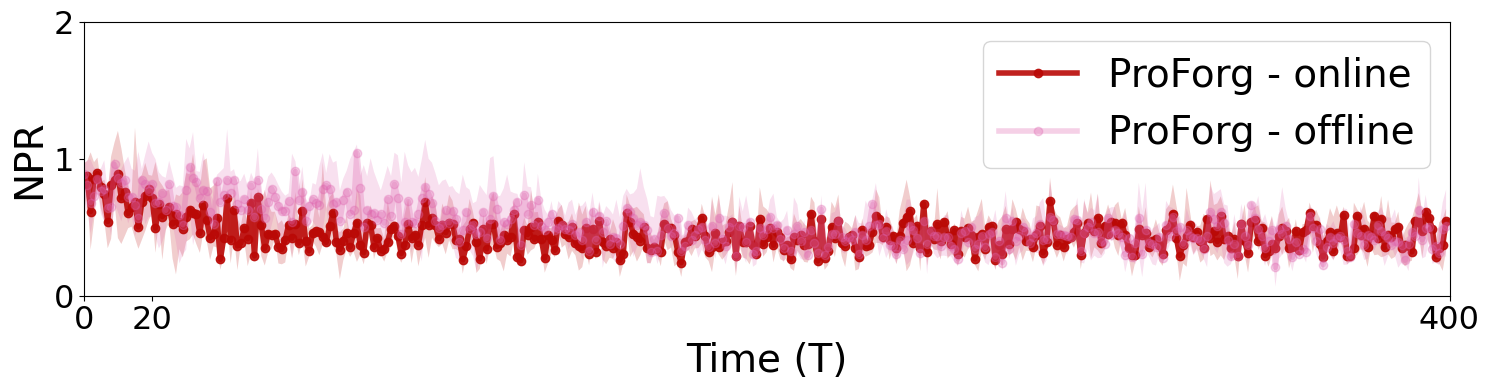

In [6]:
plt.figure(figsize=(15, 4))

linewidth = 4
fontsize = 28
pvafm_df_offline,_ = get_close_colors("PuRd", start = 0.5, delta = 0.65 , n = 2) 
_, pvafm_df_online = get_close_colors("OrRd", start = 0.2, delta = 0.65 , n = 2) 

colors = {
    "PVAFM_RF_offline":pvafm_df_offline,
    "PVAFM_RF_online":pvafm_df_online,
          }

Ts_online = np.arange(200,600,1) - 200
PREGRETS_arr = PREGRETS_arr
median = np.median(PREGRETS_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_arr, 75, axis=0)
plt.plot(Ts_online, median[:400],color=colors["PVAFM_RF_online"], lw = linewidth,marker='o',alpha = 0.9,label = 'ProForg - online')
plt.fill_between(Ts_online, q25[:400], q75[:400], color=colors["PVAFM_RF_online"], alpha=0.20, edgecolor="none")


PREGRETS_random_arr = PREGRETS_random_arr
median = np.median(PREGRETS_random_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_random_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_random_arr, 75, axis=0)

plt.plot(Ts_online, median[:400],color=colors["PVAFM_RF_offline"], lw = linewidth,marker='o',alpha = 0.3,label = 'ProForg - offline')
plt.fill_between(Ts_online, q25[:400], q75[:400], color=colors["PVAFM_RF_offline"], alpha=0.20, edgecolor="none")
plt.xticks([0,20,400],[0,20,400],fontsize = fontsize-5)
plt.xlim([0,400])
plt.ylim([0,2])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("NPR", fontsize = fontsize)
# plt.title('Prospective Regret Across Lookahead Steps - Online vs Offline',fontsize = fontsize)
plt.legend(fontsize = fontsize)
plt.tight_layout()
plt.savefig('ProForg_online.png')
